# Maynard treatment trajectory: persister-state reprogramming in EGFR-mutant lung cancer

This notebook finds a beautiful result in section 3 and takes it apart in section 4. That is the
shape of it, and it seems fair to say so in advance, because the interesting part is not the result
but what happens to it.

**Dataset.** Maynard et al. 2020 (PRJNA591860), Smart-seq2, 49 biopsies from 30 patients. EGFR- and
ALK-driven lung adenocarcinoma (among other drivers) sampled along the treatment axis:
treatment-naive (TN), residual disease (RD, the drug-tolerant persister state), and progressive
disease (PD).

**TL;DR** Maynard is genuinely good persister biology and the cleanest malignant-calling exercise in
the project. It also answers a different question than the one the stiffness model asks. Testing the
cancer-cell response prediction needs a soft-versus-stiff contrast, and dissociated patient biopsies
arranged along a treatment axis do not contain one, however many cells they contain.

## 1: Setup — load the CNV result, attach treatment stage and sequencing depth

Reading `results_maynard/cnv/cnv.h5ad`, where the malignant calls are already made, and re-attaching
`total_counts` from the per-sample resources files, since depth gets dropped during the CNV concat.

Depth is here for a different reason than it was in Kim. There it was a confound to control for;
here it is the thing being checked, because the claim that Smart-seq2 escapes Kim's problem deserves
evidence rather than assertion. `driver_gene` gets re-attached the same way, by barcode, so the EGFR
restriction below works without re-running CNV. The `score_sig` helper scores only genes actually
present in `var_names`, which keeps symbol drift from quietly shrinking a signature.

In [1]:
import re, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from scipy.stats import mannwhitneyu, kruskal
from pathlib import Path
import os

In [2]:
d = Path.cwd()
while not (d / 'workflow').is_dir() and d != d.parent:
    d = d.parent
os.chdir(d)
print('repo root:', d)

repo root: C:\Users\olesk\repos\lung_stiffness_RNAseq


In [3]:
sc.settings.verbosity = 0
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

A = sc.read_h5ad('results_maynard/cnv/cnv.h5ad')

# re-attach total_counts from the per-sample resources files (summed raw counts by barcode).
# resources files are pre-QC and carry no computed metrics, so sum X directly.
strip = lambda s: re.sub(r'-\d+$', '', str(s))
tc = {}
for f in glob.glob('resources/maynard/LT_S*.h5ad'):
    a = sc.read_h5ad(f)
    s = np.asarray(a.X.sum(1)).ravel()
    for bc, v in zip(a.obs_names, s):
        tc[strip(str(bc))] = float(v)
A.obs['total_counts'] = [tc.get(strip(b), np.nan) for b in A.obs_names]

# driver_gene is a biopsy-level attribute carried in the resources files but not propagated
# into cnv.h5ad by infer_cnv.py (which attaches only cell_type/leiden/donor_id/condition).
# Re-attach it by barcode so the EGFR restriction below works without re-running CNV.
if 'driver_gene' not in A.obs.columns:
    dg = {}
    for f in glob.glob('resources/maynard/LT_S*.h5ad'):
        o = sc.read_h5ad(f, backed='r').obs
        if 'driver_gene' in o.columns:
            for bc, v in zip(o.index, o['driver_gene'].astype(str)):
                dg[strip(str(bc))] = v
    A.obs['driver_gene'] = [dg.get(strip(b), 'NA') for b in A.obs_names]

print(f'{A.n_obs:,} cells x {A.n_vars:,} genes')
print('cnv_status:', dict(A.obs['cnv_status'].value_counts()))
print('stages:', dict(A.obs['condition'].value_counts()))

def score_sig(adata, genes, name):
    present = [g for g in genes if g in adata.var_names]
    sc.tl.score_genes(adata, present, score_name=name)
    return present

21,868 cells x 23,440 genes
cnv_status: {'reference': np.int64(12536), 'other': np.int64(4148), 'malignant': np.int64(2957), 'normal_epithelium': np.int64(2227)}
stages: {'PD': np.int64(10598), 'TN': np.int64(6828), 'RD': np.int64(4442)}


## 2: Malignant calling

Smart-seq2 sequences every cell to comparable depth, a median of about 5×10⁵ reads, which removes
the low-coverage noise that made inferCNV over-call malignancy in shallow droplet cells. That was
Kim's r = −0.79 depth confound, and a plate-based protocol should not have it.

"Should not" is worth testing rather than assuming, so the two panels below do that. On the left,
CNV-score separation by cell type, where immune and stromal cells should sit low and diploid while
epithelial cells spread into a high-CNV aneuploid mode. On the right, the same depth check Kim
failed: per-donor malignant rate against median sequencing depth.

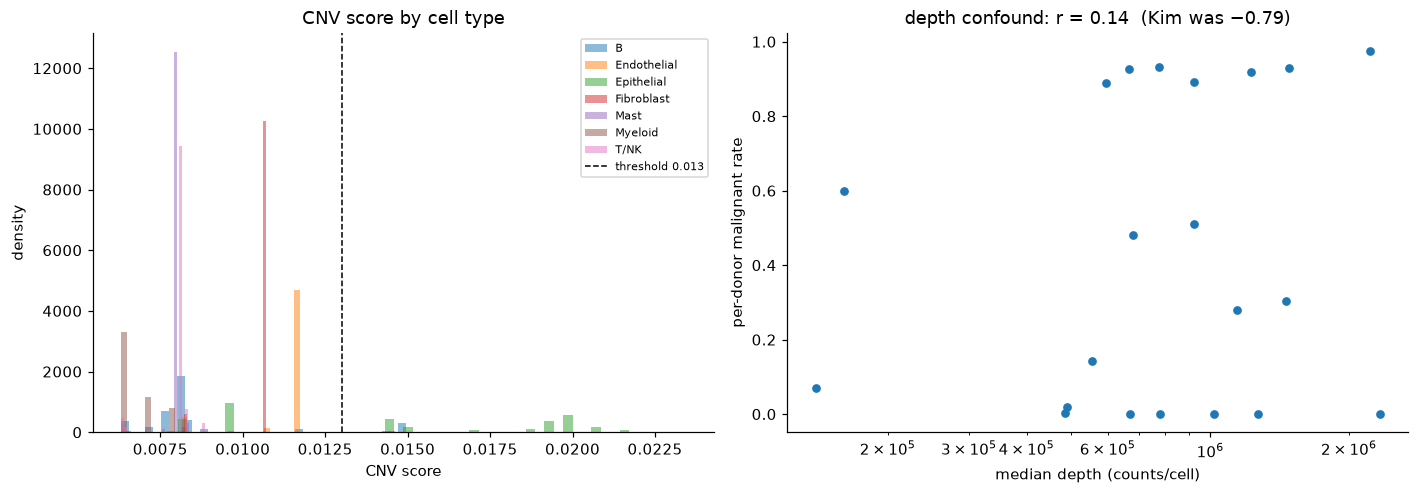

cnv_status counts: {'reference': np.int64(12536), 'other': np.int64(4148), 'malignant': np.int64(2957), 'normal_epithelium': np.int64(2227)}


In [4]:
# left: CNV score by cell type (reference low, epithelial bimodal). right: depth is NOT the driver.
VALLEY = 0.013  # density valley between diploid and aneuploid epithelium (the malignant threshold)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for ct, sub in A.obs.groupby('cell_type', observed=True):
    ax[0].hist(sub['cnv_score'], bins=60, alpha=.5, density=True, label=ct)
ax[0].axvline(VALLEY, color='k', ls='--', lw=1, label=f'threshold {VALLEY}')
ax[0].set_xlabel('CNV score'); ax[0].set_ylabel('density')
ax[0].set_title('CNV score by cell type'); ax[0].legend(fontsize=7)

# depth confound check: per-donor malignant rate vs median depth (epithelial cells)
epi = A.obs[A.obs['cell_type'] == 'Epithelial'].copy()
epi['malig'] = epi['cnv_score'] > VALLEY
g = (epi.groupby('donor_id', observed=True)
        .agg(malig_rate=('malig', 'mean'), med_depth=('total_counts', 'median'), n=('malig', 'size')))
g = g[g['n'] >= 20]
r = g['malig_rate'].corr(g['med_depth'])
ax[1].scatter(g['med_depth'], g['malig_rate'], s=22)
ax[1].set_xlabel('median depth (counts/cell)'); ax[1].set_ylabel('per-donor malignant rate')
ax[1].set_xscale('log')
ax[1].set_title(f'depth confound: r = {r:.2f}  (Kim was −0.79)')
plt.tight_layout(); plt.show()

print('cnv_status counts:', dict(A.obs['cnv_status'].value_counts()))

**Read-out.** The reference compartment (T/NK, myeloid, B) and the stroma score low, and epithelial
cells spread into a clearly separated high-CNV malignant mode. The calling works.

The right panel is the one that matters for the rest of the project. Per-donor malignant rate is
decoupled from depth, with |r| far below Kim's 0.79, so these calls are driven by real copy-number
signal instead of coverage noise. Maynard's malignant compartment can therefore carry the per-donor
claims Kim's could not, and everything below leans on that.

## 3: Model-node signatures across TN → RD → PD (EGFR malignant cells)

Restricting to confirmed-malignant, EGFR-driver cancer cells, which is the population the model is
actually about, and scoring the node signatures along the treatment axis.

`at2_regenerative` is the positive control, and a good one, because somebody else already
established the answer. The original authors found that residual-disease persisters adopt an
alveolar-regenerative, AT2-like state, so if this pipeline is capturing real persister biology that
signature has to peak at RD. If it does not, nothing else in this section is worth reading.

EGFR malignant cells by stage: {'PD': np.int64(1053), 'RD': np.int64(478), 'TN': np.int64(400)}


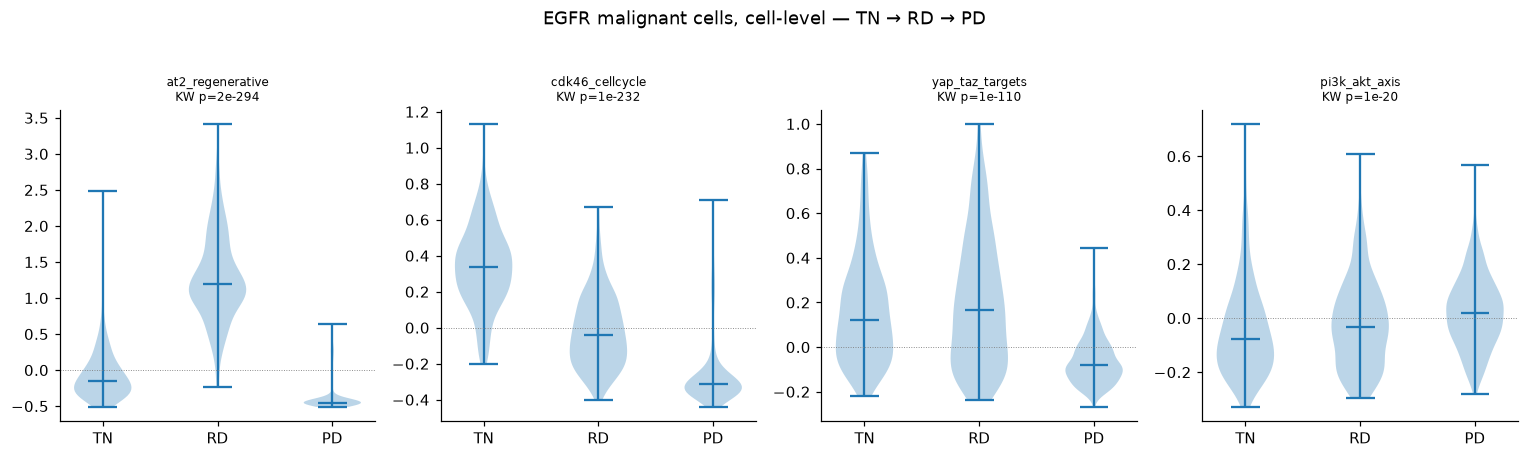


median signature score by stage (EGFR malignant, cell-level):
           pi3k_akt_axis  yap_taz_targets  cdk46_cellcycle  proliferation  at2_regenerative
condition                                                                                  
TN                -0.078            0.121            0.338         -0.042            -0.152
RD                -0.031            0.165           -0.038         -0.054             1.188
PD                 0.019           -0.081           -0.315         -0.063            -0.450


In [5]:
# confirmed-malignant AND EGFR-driver: the model is about EGFR-TKI tolerance, so mixing in
# ALK/other drivers would blur the population the prediction applies to
mal = A[(A.obs['cnv_status'] == 'malignant') & (A.obs['driver_gene'] == 'EGFR')].copy()
print('EGFR malignant cells by stage:', dict(mal.obs['condition'].value_counts()))

SIGS = {
    'pi3k_akt_axis':    ['AKT1','PIK3CA','PDPK1','FOXO3','GSK3B','RPS6KB1'],
    'yap_taz_targets':  ['CTGF','CCN2','CYR61','CCN1','ANKRD1','AMOTL2','THBS1','CAV1','TEAD1'],
    'cdk46_cellcycle':  ['CCND1','CDK4','CDK6','RB1','CDKN1A','CDKN2A','E2F1'],
    'proliferation':    ['MKI67','TOP2A','PCNA','CCNB1','CDK1','BIRC5'],
    'at2_regenerative': ['SFTPC','SFTPB','SFTPA1','NAPSA','LAMP3','ETV5'],   # positive control
}
for name, genes in SIGS.items():
    score_sig(mal, genes, name)

m = mal.obs.copy()
order = ['TN', 'RD', 'PD']
plot_sigs = ['at2_regenerative', 'cdk46_cellcycle', 'yap_taz_targets', 'pi3k_akt_axis']
fig, axes = plt.subplots(1, len(plot_sigs), figsize=(3.5*len(plot_sigs), 4.0))
for ax, name in zip(axes, plot_sigs):
    data = [m.loc[m['condition'] == s, name].values for s in order]
    ax.violinplot(data, showmedians=True)
    ax.set_xticks([1,2,3]); ax.set_xticklabels(order)
    H, p = kruskal(*data)
    ax.set_title(f'{name}\nKW p={p:.0e}', fontsize=8)
    ax.axhline(0, color='grey', lw=.6, ls=':')
plt.suptitle('EGFR malignant cells, cell-level - TN → RD → PD', y=1.03)
plt.tight_layout(); plt.show()

print('\nmedian signature score by stage (EGFR malignant, cell-level):')
print(m.groupby('condition', observed=True)[list(SIGS)].median().reindex(order).round(3).to_string())

**Read-out.** The positive control lands decisively. `at2_regenerative` jumps at RD and comes back
down (−0.15 → +1.19 → −0.45), reproducing the original authors in independently reprocessed data.

Everything else moves too. `cdk46_cellcycle` decreases monotonically (0.34 → −0.04 → −0.32),
`yap_taz_targets` peaks at RD (0.12 → 0.17 → −0.08), and `pi3k_akt_axis` climbs steadily
(−0.08 → −0.03 → +0.02). Taken at face value this is a coherent persister-state shift that happens
to include the YAP peak the model would most like to see, with p-values that look unanswerable.

Those p-values are computed over thousands of cells drawn from a handful of patients. That is the
catch, and section 4 is about how much of this survives once the patient becomes the unit.

## 4: Aggregate cells to patients

Cells sampled from one patient are not independent observations of a treatment effect. They are
repeated observations of one patient. The correct unit is the patient × stage mean, so that is what
gets computed before anything is tested.

The cost is immediate and large. Aggregating collapses thousands of cells into EGFR N = 5 RD, 5 TN,
and 3 PD, and at N = 5 the test is underpowered by construction. So direction and effect size get
reported alongside significance rather than behind it, because a non-significant result at this N
mostly reports on the size of the cohort.

In [6]:
# collapse to patient x stage means, then compare RD vs TN across patients.
# this is the step that turns thousands of cells into N=5, and section 3's p-values with it.
pdm = (m.groupby(['donor_id', 'condition'], observed=True)[list(SIGS)]
         .mean().reset_index())
print('patients per stage:', dict(pdm['condition'].value_counts()))

rows = []
for sig in SIGS:
    tn = pdm.loc[pdm['condition'] == 'TN', sig]
    rd = pdm.loc[pdm['condition'] == 'RD', sig]
    p = (mannwhitneyu(rd, tn, alternative='two-sided').pvalue
         if (len(rd) >= 3 and len(tn) >= 3) else np.nan)
    rows.append({'signature': sig, 'TN_donor_median': round(tn.median(), 3),
                 'RD_donor_median': round(rd.median(), 3),
                 'direction': 'up at RD' if rd.median() > tn.median() else 'down at RD',
                 'RDvsTN_per_donor_p': round(p, 3)})
perdonor = pd.DataFrame(rows).set_index('signature')
print()
print(perdonor.to_string())

# paired view for the patients sampled at BOTH TN and RD (within-patient trajectory, the strongest design)
wide = pdm.pivot_table(index='donor_id', columns='condition', values='cdk46_cellcycle')
paired = wide.dropna(subset=['TN', 'RD'])
if len(paired):
    print(f'\npatients sampled at both TN and RD (n={len(paired)}): cdk46 within-patient TN→RD')
    print(paired[['TN','RD']].round(3).to_string())

patients per stage: {'RD': np.int64(5), 'TN': np.int64(5), 'PD': np.int64(3)}

                  TN_donor_median  RD_donor_median   direction  RDvsTN_per_donor_p
signature                                                                         
pi3k_akt_axis              -0.073           -0.036    up at RD               0.421
yap_taz_targets             0.155            0.134  down at RD               1.000
cdk46_cellcycle             0.255           -0.041  down at RD               0.151
proliferation               0.060           -0.028  down at RD               0.151
at2_regenerative            0.595            1.214    up at RD               0.841

patients sampled at both TN and RD (n=2): cdk46 within-patient TN→RD
condition     TN     RD
donor_id               
TH218     -0.135 -0.156
TH226      0.350  0.133


C:\Users\olesk\AppData\Local\Temp\ipykernel_24256\466630008.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pdm.pivot_table(index='donor_id', columns='condition', values='cdk46_cellcycle')


**Read-out (per-donor).** Almost nothing reaches significance at the patient level, and the pattern
of what fails is more informative than the failing itself.

- **`yap_taz_targets` does not survive.** TN 0.155 against RD 0.134, p ≈ 1.0. The cell-level YAP
  peak at RD, which was the most model-specific signal in section 3, disappears completely once
  patients are the unit. It was variation among cells within patients, not a shift the patients had
  in common.
- **`pi3k_akt_axis`** is directionally up, but the effect is tiny and non-significant (p ≈ 0.42).
- **`at2_regenerative`** holds directionally (0.60 → 1.21) at p ≈ 0.84. This one is worth sitting
  with. Even the original authors' headline finding, which is almost certainly real, comes out
  directional rather than significant at this N, which says something about the cohort size and
  nothing about their result.
- **`cdk46_cellcycle`** is the one effect that holds directionally per donor (0.255 → −0.041, the
  smallest p at ≈ 0.15), and it holds within the paired patients sampled at both stages too.

The cell-level significances were pseudoreplication. `at2_regenerative` is the honest control on
that conclusion, since it shows the per-donor test failing to detect something that is very likely
there, which means "did not survive" has to be read as underpowered rather than disproven.

The one durable effect is the CDK4/6 decrease, and the next section deals with it, because its
direction is the opposite of what the stiffness model predicts.

## 5: The CDK4/6 decrease is persister quiescence, not a stiffness readout

The stiffness model predicts that a stiffer environment raises cyclin D–CDK4/6, giving more dividing
cells and a smaller pool of drug-sensitive slow dividers. Maynard shows CDK4/6 going down in the
persister state. Opposite direction.

The plainest reading is that drug-tolerant persisters exit the cell cycle in order to survive the
TKI. Quiescence is the defining feature of the persister phenotype, and it has nothing to do with
matrix stiffness, so this is not the model's prediction failing. It is a different axis moving the
same gene set. Reading it as evidence against the model would require Maynard to have varied
stiffness, and section 6 is about why it did not.

The plot below makes the direction explicit and pairs CDK4/6 with a generic proliferation signature.
If quiescence is the explanation, the two should move together.

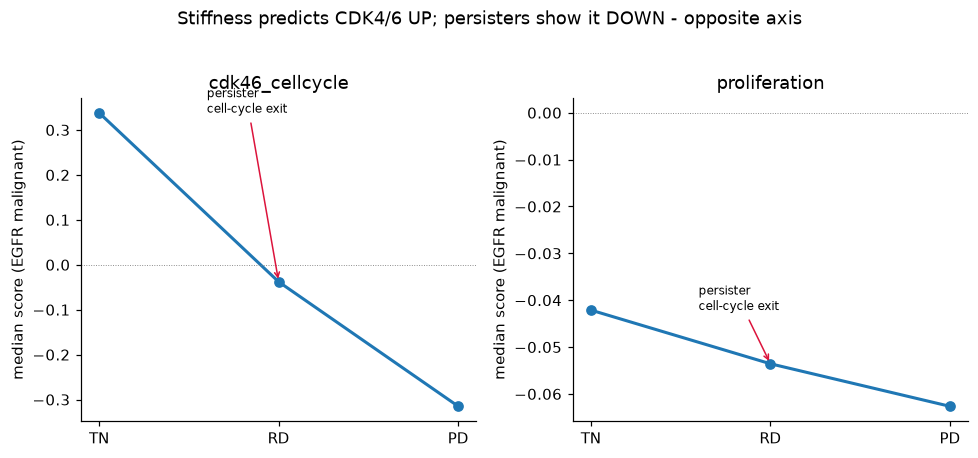

In [7]:
# CDK4/6 and proliferation both fall into the persister (RD) state -> cell-cycle exit, not stiffening
fig, ax = plt.subplots(1, 2, figsize=(9, 4.0))
for j, sig in enumerate(['cdk46_cellcycle', 'proliferation']):
    score_sig(mal, SIGS.get(sig, ['MKI67','TOP2A','PCNA','CCNB1','CDK1','BIRC5']), sig)
    med = mal.obs.groupby('condition', observed=True)[sig].median().reindex(order)
    ax[j].plot(order, med.values, 'o-', lw=2)
    ax[j].axhline(0, color='grey', lw=.6, ls=':')
    ax[j].set_title(sig); ax[j].set_ylabel('median score (EGFR malignant)')
    ax[j].annotate('persister\ncell-cycle exit', xy=(1, med.values[1]),
                   xytext=(0.6, med.max()), fontsize=8,
                   arrowprops=dict(arrowstyle='->', color='crimson'))
fig.suptitle('Stiffness predicts CDK4/6 UP; persisters show it DOWN - opposite axis', y=1.03)
plt.tight_layout(); plt.show()

**Read-out.** Both cell-cycle signatures drop into RD and stay low, moving together the way
quiescence predicts. The persisters are not cycling, and CDK4/6 is falling because of that rather
than because of anything mechanical.

## 6: Why Maynard cannot test the stiffness prediction, even in principle

The model's untested claim is that cancer cells in a stiffer environment raise FAK, AKT, YAP, and
proliferation relative to cancer cells in a softer one. Testing that needs a stiffness contrast: two
populations differing in stiffness, with stiffness either measured or manipulated, and cell identity
held fixed.

Maynard's axis is treatment stage, which is a different thing wearing similar clothing. TN, RD, and
PD differ in drug exposure, clonal selection, persister survival, and elapsed time, all at once and
all in the same direction. No stage differs from another only in stiffness, and stiffness is never
measured on any cell in the dataset. So no comparison across TN, RD, and PD can be attributed to
stiffness, whatever the signatures happen to do, and a larger cohort would not change that.

The same structural limit applies to Kim's tumor-versus-normal axis, which confounds malignancy with
essentially everything else about the tissue. Dissociated patient-biopsy scRNA-seq does not carry
the variable this claim is about, and this is the point in the project where that became clear
enough to act on.

In [8]:
# make the confounding explicit: the 'axis' here is treatment, and it bundles several variables at once.
summary = pd.DataFrame({
    'stage': ['TN', 'RD', 'PD'],
    'meaning': ['treatment-naive baseline',
                'residual disease (drug-tolerant persister)',
                'progressive disease (acquired resistance)'],
    'differs from TN by': ['-',
                            'drug exposure + persister survival + time',
                            'drug exposure + selection + resistance + time'],
    'stiffness measured?': ['no', 'no', 'no'],
    'EGFR malignant cells': [int((mal.obs['condition']=='TN').sum()),
                             int((mal.obs['condition']=='RD').sum()),
                             int((mal.obs['condition']=='PD').sum())],
    'EGFR patients': [pdm[pdm['condition']=='TN']['donor_id'].nunique(),
                      pdm[pdm['condition']=='RD']['donor_id'].nunique(),
                      pdm[pdm['condition']=='PD']['donor_id'].nunique()],
})
print(summary.to_string(index=False))

stage                                    meaning                            differs from TN by stiffness measured?  EGFR malignant cells  EGFR patients
   TN                   treatment-naive baseline                                             —                  no                   400              5
   RD residual disease (drug-tolerant persister)     drug exposure + persister survival + time                  no                   478              5
   PD  progressive disease (acquired resistance) drug exposure + selection + resistance + time                  no                  1053              3


**Read-out.** Every stage difference bundles several variables at once and none of them isolates
stiffness, which makes this axis the wrong instrument for the cancer-cell response claim regardless
of sample size. The per-stage cell and patient counts print alongside, partly for transparency and
partly because the gap between the cell counts and the patient counts is the whole lesson of
section 4 laid out in one table.

## 7: Conclusions

**What Maynard establishes.** A cleanly resolved malignant compartment with no depth confound, which
makes it the cleanest CNV calling in the project. And real persister-state reprogramming in
EGFR-mutant cancer cells: the alveolar-regenerative AT2 program switches on at residual disease,
reproducing the original authors, and cyclin D–CDK4/6 decreases as persisters exit the cell cycle.
The CDK4/6 effect is the one signal that holds directionally per donor.

**What Maynard does not establish.** The mechanotransduction response the stiffness model predicts.
The cell-level YAP and AKT shifts are pseudoreplication and do not survive aggregation to the
patient (YAP, RD against TN, p ≈ 1.0 across N = 5). The CDK4/6 effect that does survive runs
opposite to the stiffness prediction, and it runs that way because it is persister quiescence rather
than stiffening.

This matches Kim, where malignant-cell YAP and AKT came out flat to lower. The cancer-cell stiffness
response is not demonstrated in either patient dataset, and more to the point it cannot be, since
neither dataset contains a soft-versus-stiff comparison. Two datasets failing the same way for the
same structural reason are not two pieces of evidence against the model. They are one piece of
evidence about what a patient biopsy can be asked.

The next contrast therefore has to be a controlled one: lung cancer cells on soft against stiff
substrates with a transcriptomic readout. The A549 1 kPa versus 50 kPa RNA-seq from Cosgrove and
Gersbach (*Science*, 2024) is exactly that and this pipeline can score it directly, with
EGFR-specific confirmation available in PC9 and HCC827 hydrogel data. Spatial NSCLC would work too,
defining stiff and soft niches by local CAF and ECM density and comparing one tumor's cancer cells
across them. Paired with the stromal result Kim and Tsukui do support, where tumors build the stiff
niche, that contrast tests the half of the model still standing open: whether the cancer cells
respond to it.